# Loan Approval Prediction - Model Development

This notebook trains, evaluates, compares, and saves classification models using the current `loans.csv` dataset.

**Workflow:** Load data -> Validate schema -> Train/test split -> Scale features -> Train models -> Evaluate -> Compare -> Save final pipeline -> Test a new applicant

## 1. Import Libraries

In [18]:
import pathlib
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

pd.set_option("display.max_columns", None)
%matplotlib inline

## 2. Load the Current Dataset

The project now uses `../data/loans.csv`. Its input columns are `income`, `credit_score`, `loan_amount`, and `employment_years`; the target is `loan_status`.

In [19]:
DATA_PATH = pathlib.Path("../data/loans.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset loaded successfully.
Dataset shape: (1000, 5)
Columns: ['income', 'credit_score', 'loan_amount', 'employment_years', 'loan_status']


,income,credit_score,loan_amount,employment_years,loan_status
0,141958,760,43525,16,1
1,35795,846,37556,4,1
2,20860,552,17595,11,1
3,123694,689,6969,10,1
4,148106,555,48753,14,0


## 3. Dataset Overview

In [20]:
print('Columns:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum())

Columns:
['income', 'credit_score', 'loan_amount', 'employment_years', 'loan_status']

Data types:
income              int64
credit_score        int64
loan_amount         int64
employment_years    int64
loan_status         int64
dtype: object

Missing values:
income              0
credit_score        0
loan_amount         0
employment_years    0
loan_status         0
dtype: int64


## 4. Define Features and Target

The four numeric applicant fields are used as predictors, and `loan_status` is the binary target (`1` = approved, `0` = not approved).

In [21]:
FEATURE_COLUMNS = [
    "income",
    "credit_score",
    "loan_amount",
    "employment_years",
]
TARGET_COLUMN = "loan_status"

X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

print("Features:", FEATURE_COLUMNS)
print("Target:", TARGET_COLUMN)
print("\nTarget distribution:")
print(y.value_counts().sort_index())
print("\nTarget percentage:")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

Features: ['income', 'credit_score', 'loan_amount', 'employment_years']
Target: loan_status

Target distribution:
loan_status
0    500
1    500
Name: count, dtype: int64

Target percentage:
loan_status
0    50.0
1    50.0
Name: proportion, dtype: float64


## 5. Train/Test Split

A stratified 80/20 split is used so the class distribution is approximately preserved in both sets.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (800, 4)
X_test : (200, 4)
y_train: (800,)
y_test : (200,)


## 6. Define Numeric Features

All four predictors in `loans.csv` are numeric, so the model pipeline only needs standard scaling.

In [23]:
numerical_features = FEATURE_COLUMNS

print("Numerical features:", numerical_features)
print("Categorical features: []")

Numerical features: ['income', 'credit_score', 'loan_amount', 'employment_years']
Categorical features: []


## 7. Create the Preprocessing Pipeline

Standardization is fitted inside the pipeline using only the training data, preventing data leakage.

In [24]:
preprocessor = StandardScaler()

print("StandardScaler created for numeric features.")

StandardScaler created for numeric features.


## 8. Create Classification Models

Three baseline classifiers are trained and compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest

In [25]:
logistic_model = Pipeline([
    ("scaler", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

decision_tree_model = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42)),
])

random_forest_model = Pipeline([
    ("model", RandomForestClassifier(n_estimators=100, random_state=42)),
])

print("All model pipelines created successfully.")

All model pipelines created successfully.


## 9. Train the Models

In [26]:
logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print('All models trained successfully.')

All models trained successfully.


## 10. Generate Test Predictions

In [27]:
y_pred_logistic = logistic_model.predict(X_test)
y_pred_tree = decision_tree_model.predict(X_test)
y_pred_forest = random_forest_model.predict(X_test)

print('Predictions generated successfully.')

Predictions generated successfully.


## 11. Evaluate the Models

In [28]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

results = [
    evaluate_model("Logistic Regression", y_test, y_pred_logistic),
    evaluate_model("Decision Tree", y_test, y_pred_tree),
    evaluate_model("Random Forest", y_test, y_pred_forest),
]

results_df = pd.DataFrame(results)
results_df.sort_values("F1 Score", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.995,0.990099,1.00,0.995025
1,Random Forest,0.970,0.970000,0.97,0.970000
2,Decision Tree,0.945,0.949495,0.94,0.944724


## 12. Model Comparison Visualization

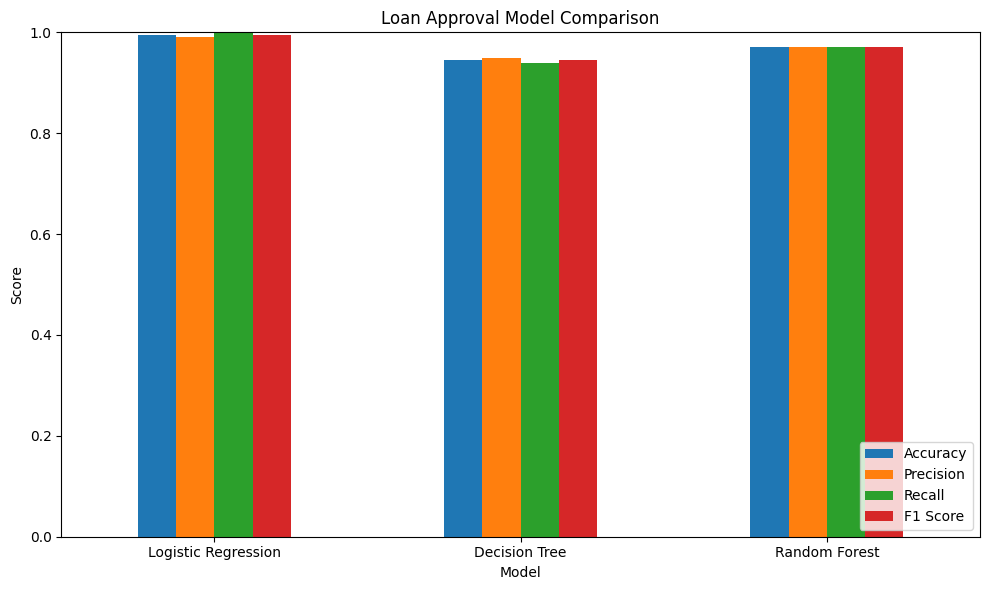

In [29]:
plot_df = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']]

plot_df.plot(kind='bar', figsize=(10, 6))
plt.title('Loan Approval Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 13. Confusion Matrices

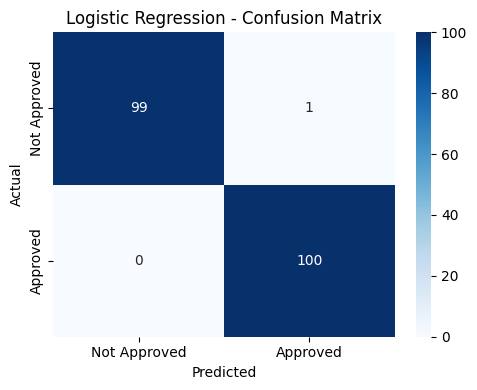

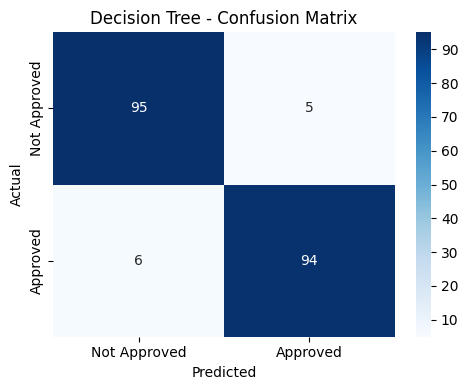

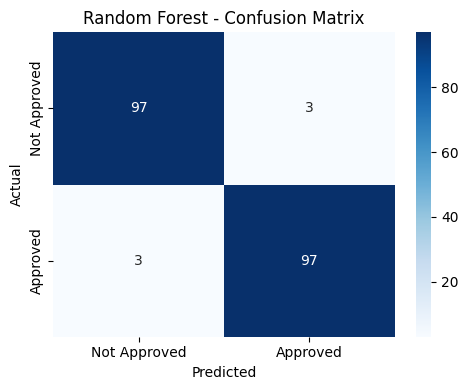

In [30]:
model_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest,
}

for name, predictions in model_predictions.items():
    cm = confusion_matrix(y_test, predictions, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Approved", "Approved"],
        yticklabels=["Not Approved", "Approved"],
    )
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 14. Final Model Classification Report

Logistic Regression is selected as the final candidate to match the model pipeline currently used by the FastAPI backend.

In [31]:
final_model = logistic_model
final_predictions = y_pred_logistic

print("Logistic Regression - Classification Report")
print(
    classification_report(
        y_test,
        final_predictions,
        labels=[0, 1],
        target_names=["Not Approved", "Approved"],
        zero_division=0,
    )
)

Logistic Regression - Classification Report
              precision    recall  f1-score   support

Not Approved       1.00      0.99      0.99       100
    Approved       0.99      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



## 15. Save the Final Model

The complete pipeline is saved so the backend can send raw applicant fields directly to it. The pipeline automatically performs the same encoding and scaling used during training.

In [34]:
MODEL_DIR = pathlib.Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PIPELINE_PATH = MODEL_DIR / "loan_approval_model.pkl"
PREPROCESSOR_PATH = MODEL_DIR / "loan_approval_preprocessor.pkl"
CLASSIFIER_PATH = MODEL_DIR / "loan_approval_classifier.pkl"
RESULTS_PATH = MODEL_DIR / "model_comparison.csv"

joblib.dump(final_model, PIPELINE_PATH)
joblib.dump(final_model.named_steps["scaler"], PREPROCESSOR_PATH)
joblib.dump(final_model.named_steps["model"], CLASSIFIER_PATH)
results_df.to_csv(RESULTS_PATH, index=False)

print("Files saved successfully:")
for path in [PIPELINE_PATH, PREPROCESSOR_PATH, CLASSIFIER_PATH, RESULTS_PATH]:
    print(path.resolve())

Files saved successfully:
D:\Workplace\Capstone-Project\Supervised_Learning\ADV_LOAN_APPROVAL\loan-approval-ml\models\loan_approval_model.pkl
D:\Workplace\Capstone-Project\Supervised_Learning\ADV_LOAN_APPROVAL\loan-approval-ml\models\loan_approval_preprocessor.pkl
D:\Workplace\Capstone-Project\Supervised_Learning\ADV_LOAN_APPROVAL\loan-approval-ml\models\loan_approval_classifier.pkl
D:\Workplace\Capstone-Project\Supervised_Learning\ADV_LOAN_APPROVAL\loan-approval-ml\models\model_comparison.csv


## 16. Test the Saved Model with a New Applicant

This checks that the saved pipeline can make a prediction from raw feature values in the same format that the backend will receive.

In [33]:
loaded_model = joblib.load(PIPELINE_PATH)

new_applicant = pd.DataFrame([
    {
        "income": 50000,
        "credit_score": 700,
        "loan_amount": 20000,
        "employment_years": 5,
    }
])[FEATURE_COLUMNS]

prediction = int(loaded_model.predict(new_applicant)[0])
probabilities = loaded_model.predict_proba(new_applicant)[0]
approved_index = list(loaded_model.classes_).index(1)

print("Predicted Loan Status:", prediction)
print(f"Approval Decision: {'Approved' if prediction == 1 else 'Not Approved'}")
print(f"Approval Probability: {probabilities[approved_index]:.2%}")

Predicted Loan Status: 1
Approval Decision: Approved
Approval Probability: 97.41%


## 17. ML Handoff

The final model pipeline is now ready for backend integration.

### Output
- `models/loan_approval_model.pkl` — complete preprocessing + Logistic Regression pipeline
- `models/loan_approval_preprocessor.pkl` — preprocessing component
- `models/loan_approval_classifier.pkl` — Logistic Regression classifier
- `models/model_comparison.csv` — model evaluation results

### Backend flow
`Applicant Input → Saved Pipeline → Prediction → FastAPI → Streamlit`